## This notebook is for plotting CVs of trajectories and visualization with chemiscope

In [1]:
import chemiscope
import torch 
import numpy as np
import os
from typing import Dict, List, Optional
from scipy.stats import moment
from metatensor.torch import Labels, TensorBlock, TensorMap
from metatomic.torch import (
    AtomisticModel,
    ModelCapabilities,
    ModelEvaluationOptions,
    ModelMetadata,
    ModelOutput,
    System,
    systems_to_torch,
    load_atomistic_model
)
from featomic.torch import SoapPowerSpectrum
from vesin.torch import NeighborList
from ase.io import read
import matplotlib.pyplot as plt
from scipy.signal import welch

In [3]:
cwd = "/Users/markusfasching/EPFL/Work/project-SOAP/scripts/SOAP-time-code/metad/pavanshort/high-freq"
soaps = ['866']
methods = ['PCAFull']#, 'SpatialPCA', 'IVAC', 'SpatialIVACnorm']
areas = [80.0]
thermos = ['bussi']
files = [os.path.join(cwd, f'run{soap}', method, f'soap_wrapper_zmin60.0_zmax{area}.pt') for method in methods for soap in soaps for area in areas]
models = [load_atomistic_model(file, extensions_directory=os.path.abspath(file)) for file in files]

RuntimeError: open file failed because of errno 2 on fopen: No such file or directory, file path: /Users/markusfasching/EPFL/Work/project-SOAP/scripts/SOAP-time-code/metad/pavanshort/high-freq/run866/PCAFull/soap_wrapper_zmin60.0_zmax80.0.pt

In [2]:
id = "runfourier-skip1"
id = "runfourier"

In [3]:
results = f"/Users/markusfasching/EPFL/Work/project-SOAP/scripts/SOAP-time-code/results/icewaterinterface4ns_oxygen_proper_testset_1ps/v0/SOAP/644/{id}"
intervals = [1, 10, 100, 250]
#intervals = [1]
methods = ['PCAFull']
lags = ["ivac" if method=="IVAC" else 0 for method in methods]
files = [os.path.join(results, method, f"interval_{interval}", f"lag_{lags[i]}", "sigma_0/ridge_a1e-05/SOAP_644_[8]/model_soap.pt") for i, method in enumerate(methods) for interval in intervals]
PCAmodels = [load_atomistic_model(file, extensions_directory=os.path.abspath(file)) for file in files]


[W317 16:18:54.891604000 model.cpp:178] Warning: 'features' defines 2 output variants and 'features' has an empty description. Consider adding meaningful descriptions helping users to distinguish between them. (function set_outputs)
[W317 16:18:54.891617000 model.cpp:178] Warning: 'features' defines 2 output variants and 'features/per_atom' has an empty description. Consider adding meaningful descriptions helping users to distinguish between them. (function set_outputs)
[W317 16:18:54.933548000 model.cpp:178] Warning: 'features' defines 2 output variants and 'features' has an empty description. Consider adding meaningful descriptions helping users to distinguish between them. (function set_outputs)
[W317 16:18:54.933562000 model.cpp:178] Warning: 'features' defines 2 output variants and 'features/per_atom' has an empty description. Consider adding meaningful descriptions helping users to distinguish between them. (function set_outputs)
[W317 16:18:54.957516000 model.cpp:178] Warning: '

In [4]:
id = "runfourier-skip1"
id = "runfourier"
results = f"/Users/markusfasching/EPFL/Work/project-SOAP/scripts/SOAP-time-code/results/icewaterinterface4ns_oxygen_proper_testset_1ps/v0/SOAP/644/{id}"
intervals = [1, 10, 50, 100, 250]
intervals = [1]
methods = ['IVAC']
lags = ["ivac" if method=="IVAC" else 0 for method in methods]
files = [os.path.join(results, method, f"interval_{interval}", f"lag_{lags[i]}", "sigma_0/ridge_a1e-05/SOAP_644_[8]/model_soap.pt") for i, method in enumerate(methods) for interval in intervals]
IVACmodels = [load_atomistic_model(file, extensions_directory=os.path.abspath(file)) for file in files]

id = "runfourier-skip1-sigma2factor1e-4"
results = f"/Users/markusfasching/EPFL/Work/project-SOAP/scripts/SOAP-time-code/results/icewaterinterface4ns_oxygen_proper_testset_1ps/v0/SOAP/644/{id}"
intervals = [1, 10, 50, 100, 250]
intervals = [1]
methods = ['IVAC']
lags = ["ivac" if method=="IVAC" else 0 for method in methods]
files = [os.path.join(results, method, f"interval_{interval}", f"lag_{lags[i]}", "sigma_0/ridge_a1e-05/SOAP_644_[8]/model_soap.pt") for i, method in enumerate(methods) for interval in intervals]
IVACmodels += [load_atomistic_model(file, extensions_directory=os.path.abspath(file)) for file in files]

id = "runfourier-skip1-sigma2factor1e-3"
results = f"/Users/markusfasching/EPFL/Work/project-SOAP/scripts/SOAP-time-code/results/icewaterinterface4ns_oxygen_proper_testset_1ps/v0/SOAP/644/{id}"
intervals = [1, 10, 50, 100, 250]
intervals = [1]
methods = ['IVAC']
lags = ["ivac" if method=="IVAC" else 0 for method in methods]
files = [os.path.join(results, method, f"interval_{interval}", f"lag_{lags[i]}", "sigma_0/ridge_a1e-05/SOAP_644_[8]/model_soap.pt") for i, method in enumerate(methods) for interval in intervals]
IVACmodels += [load_atomistic_model(file, extensions_directory=os.path.abspath(file)) for file in files]

id = "runfourier-skip1-sigma2factor1e-2"
results = f"/Users/markusfasching/EPFL/Work/project-SOAP/scripts/SOAP-time-code/results/icewaterinterface4ns_oxygen_proper_testset_1ps/v0/SOAP/644/{id}"
intervals = [1, 10, 50, 100, 250]
intervals = [1]
methods = ['IVAC']
lags = ["ivac" if method=="IVAC" else 0 for method in methods]
files = [os.path.join(results, method, f"interval_{interval}", f"lag_{lags[i]}", "sigma_0/ridge_a1e-05/SOAP_644_[8]/model_soap.pt") for i, method in enumerate(methods) for interval in intervals]
IVACmodels += [load_atomistic_model(file, extensions_directory=os.path.abspath(file)) for file in files]

id = "runfourier-skip1-sigma2factor1e-1"
results = f"/Users/markusfasching/EPFL/Work/project-SOAP/scripts/SOAP-time-code/results/icewaterinterface4ns_oxygen_proper_testset_1ps/v0/SOAP/644/{id}"
intervals = [1, 10, 50, 100, 250]
intervals = [1]
methods = ['IVAC']
lags = ["ivac" if method=="IVAC" else 0 for method in methods]
files = [os.path.join(results, method, f"interval_{interval}", f"lag_{lags[i]}", "sigma_0/ridge_a1e-05/SOAP_644_[8]/model_soap.pt") for i, method in enumerate(methods) for interval in intervals]
IVACmodels += [load_atomistic_model(file, extensions_directory=os.path.abspath(file)) for file in files]

id = "runfourier-skip1-sigma2factor1e0"
results = f"/Users/markusfasching/EPFL/Work/project-SOAP/scripts/SOAP-time-code/results/icewaterinterface4ns_oxygen_proper_testset_1ps/v0/SOAP/644/{id}"
intervals = [1, 10, 50, 100, 250]
intervals = [1]
methods = ['IVAC']
lags = ["ivac" if method=="IVAC" else 0 for method in methods]
files = [os.path.join(results, method, f"interval_{interval}", f"lag_{lags[i]}", "sigma_0/ridge_a1e-05/SOAP_644_[8]/model_soap.pt") for i, method in enumerate(methods) for interval in intervals]
IVACmodels += [load_atomistic_model(file, extensions_directory=os.path.abspath(file)) for file in files]

id = "runfourier-skip1-sigma2factor1e1"
results = f"/Users/markusfasching/EPFL/Work/project-SOAP/scripts/SOAP-time-code/results/icewaterinterface4ns_oxygen_proper_testset_1ps/v0/SOAP/644/{id}"
intervals = [1, 10, 50, 100, 250]
intervals = [1]
methods = ['IVAC']
lags = ["ivac" if method=="IVAC" else 0 for method in methods]
files = [os.path.join(results, method, f"interval_{interval}", f"lag_{lags[i]}", "sigma_0/ridge_a1e-05/SOAP_644_[8]/model_soap.pt") for i, method in enumerate(methods) for interval in intervals]
IVACmodels += [load_atomistic_model(file, extensions_directory=os.path.abspath(file)) for file in files]

id = "runfourier-skip1-sigma2factor1e2"
results = f"/Users/markusfasching/EPFL/Work/project-SOAP/scripts/SOAP-time-code/results/icewaterinterface4ns_oxygen_proper_testset_1ps/v0/SOAP/644/{id}"
intervals = [1, 10, 50, 100, 250]
intervals = [1]
methods = ['IVAC']
lags = ["ivac" if method=="IVAC" else 0 for method in methods]
files = [os.path.join(results, method, f"interval_{interval}", f"lag_{lags[i]}", "sigma_0/ridge_a1e-05/SOAP_644_[8]/model_soap.pt") for i, method in enumerate(methods) for interval in intervals]
IVACmodels += [load_atomistic_model(file, extensions_directory=os.path.abspath(file)) for file in files]


[W317 16:18:58.991565000 model.cpp:178] Warning: 'features' defines 2 output variants and 'features' has an empty description. Consider adding meaningful descriptions helping users to distinguish between them. (function set_outputs)
[W317 16:18:58.991581000 model.cpp:178] Warning: 'features' defines 2 output variants and 'features/per_atom' has an empty description. Consider adding meaningful descriptions helping users to distinguish between them. (function set_outputs)
[W317 16:18:58.020839000 model.cpp:178] Warning: 'features' defines 2 output variants and 'features' has an empty description. Consider adding meaningful descriptions helping users to distinguish between them. (function set_outputs)
[W317 16:18:58.020852000 model.cpp:178] Warning: 'features' defines 2 output variants and 'features/per_atom' has an empty description. Consider adding meaningful descriptions helping users to distinguish between them. (function set_outputs)
[W317 16:18:58.046218000 model.cpp:178] Warning: '

In [5]:
id = "runfourier-skip1"
id = "runfourier"
results = f"/Users/markusfasching/EPFL/Work/project-SOAP/scripts/SOAP-time-code/results/icewaterinterface4ns_oxygen_proper_testset_1ps/v0/SOAP/644/{id}"
intervals = [1]
methods = ['SpatialIVACnorm']
lags = ["ivac" if method=="IVAC" else 0 for method in methods]
files = [os.path.join(results, method, f"interval_{interval}", f"lag_{lags[i]}", "sigma_0/ridge_a1e-05/SOAP_644_[8]cut_6/model_soap.pt") for i, method in enumerate(methods) for interval in intervals]
SpatialIVACmodels = [load_atomistic_model(file, extensions_directory=os.path.abspath(file)) for file in files]



[W317 16:19:02.663802000 model.cpp:178] Warning: 'features' defines 2 output variants and 'features' has an empty description. Consider adding meaningful descriptions helping users to distinguish between them. (function set_outputs)
[W317 16:19:02.663817000 model.cpp:178] Warning: 'features' defines 2 output variants and 'features/per_atom' has an empty description. Consider adding meaningful descriptions helping users to distinguish between them. (function set_outputs)


In [6]:
results = f"/Users/markusfasching/EPFL/Work/project-SOAP/scripts/SOAP-time-code/results/icewaterinterface4ns_oxygen_proper_testset_1ps/v0/SOAP/644/{id}"
intervals = [1]
methods = ['SpatialPCA']
lags = ["ivac" if method=="IVAC" else 0 for method in methods]
files = [os.path.join(results, method, f"interval_{interval}", f"lag_{lags[i]}", "sigma_1000/ridge_a1e-05/SOAP_644_[8]cut_6/model_soap.pt") for i, method in enumerate(methods) for interval in intervals]
SpatialPCAmodels = [load_atomistic_model(file, extensions_directory=os.path.abspath(file)) for file in files]

RuntimeError: open file failed because of errno 2 on fopen: No such file or directory, file path: /Users/markusfasching/EPFL/Work/project-SOAP/scripts/SOAP-time-code/results/icewaterinterface4ns_oxygen_proper_testset_1ps/v0/SOAP/644/runfourier/SpatialPCA/interval_1/lag_0/sigma_1000/ridge_a1e-05/SOAP_644_[8]cut_6/model_soap.pt

In [7]:
systems = systems_to_torch(structures[:1])

NameError: name 'structures' is not defined

In [8]:
system = systems[0]
types = system.types
mask = types == 1

new = System(types=types[mask], positions=system.positions[mask], cell=system.cell, pbc=system.pbc)

NameError: name 'systems' is not defined

In [9]:
import torch 
import numpy as np
from typing import Dict, List, Optional, Tuple
from scipy.stats import moment
from metatensor.torch import Labels, TensorBlock, TensorMap
from metatomic.torch import (
    AtomisticModel,
    ModelCapabilities,
    ModelEvaluationOptions,
    ModelMetadata,
    ModelOutput,
    System,
    systems_to_torch,
    load_atomistic_model
)
from featomic.torch import SoapPowerSpectrum
import argparse
from pathlib import Path
from torch.profiler import record_function


class Wrapper(torch.nn.Module):
    def __init__(self, model, zmin, zmax, nlistoptions):
        super().__init__()
        self.model = model
        self.zmin = zmin
        self.zmax = zmax
        self.nlistoptions = nlistoptions
    

    def wrap(self, systems: List[System]):
        cell = systems[0].cell
        z = systems[0].positions[:, 2]
        shift = ()//(cell[2, 2] - cell[2, 2])


    def pre_selected(
            self, 
            systems: List[System],
            selected_atoms: Optional[Labels]
    ) -> Labels:
        if selected_atoms is None:
            pos = systems[0].positions
            mask = (pos[:, 2] > self.zmin) & (pos[:, 2] < self.zmax)
            indices = torch.arange(len(pos))
            if len(indices[mask]) == 0:
                newselected_atoms = Labels(
                    names=["system", "atom"],
                    values=torch.tensor([[0, int(i)] for i in [0]]),
                )
                return newselected_atoms

            newselected_atoms = Labels(
                names=["system", "atom"],
                values=torch.tensor([[0, int(i)] for i in indices[mask]]),
            )
        else:
            pos = systems[0].positions[selected_atoms.values[:,1]]
            mask = (pos[:, 2] > self.zmin) & (pos[:, 2] < self.zmax)
            newselected_atoms = Labels(
                names=selected_atoms.names,
                values=selected_atoms.values[mask],
            )
        return newselected_atoms

    def forward(
        self,
        systems: List[System],
        outputs: Dict[str, ModelOutput],
        selected_atoms: Optional[Labels],
    ) -> Dict[str, TensorMap]:
        
        newselected_atoms = self.pre_selected(systems, selected_atoms)
        features = self.model(systems, outputs, newselected_atoms)
        return features

    def requested_neighbor_lists(self):
        return self.nlistoptions

    def save_model(self, metadata, capabilities, path='.', name='wrapper'):
        wrapper = AtomisticModel(self, metadata, capabilities)
        print("saving to {}/{}.pt".format(path, name))
        wrapper.save("{}/{}.pt".format(path, name), collect_extensions=f"{path}/extensions")


In [10]:
def get_wrapper(model, zmin, zmax):
    wrapper = Wrapper(model.module, zmin, zmax, nlistoptions=model.requested_neighbor_lists())
    wrapper.eval()
    wrapper = AtomisticModel(wrapper, model.metadata(), model.capabilities())
    return wrapper

In [11]:
zmin = 60
zmax = 67
models = PCAmodels + IVACmodels #+ SpatialIVACmodels + SpatialPCAmodels
wrappers = [get_wrapper(model, zmin, zmax) for model in models]

In [12]:
cwd = '/Users/markusfasching/EPFL/Work/project-SOAP/scripts/SOAP-time-code/metad/test'
model_name = ['soap_wrapper_zmin60.0_zmax{area}.pt' for area in areas]
model_name = '/Users/markusfasching/EPFL/Work/project-SOAP/scripts/SOAP-time-code/results/amorph-metad-1ps/v0/SOAP/866/all/PCAfull/interval_1/lag_0/sigma_0/ridge_a1e-05/SOAP_866_[8]/model_soap.pt'
trj_name = 'positions.lammpstrj'

NameError: name 'areas' is not defined

In [13]:
# Load model
CVmodel = load_atomistic_model(os.path.join(cwd, model_name), extensions_directory='.')


NameError: name 'model_name' is not defined

#### Load trajectory for testing

In [14]:
#dt 1fs:
structures = read('/Users/markusfasching/EPFL/Work/project-SOAP/scripts/SOAP-time-code/metad/pavanshort/high-freq/positions.lammpstrj', index=':1000')

#dt 100fs:
#structures = read('/Users/markusfasching/EPFL/Work/project-SOAP/scripts/SOAP-time-code/data/icemeltinterface/nobias/positions.lammpstrj', index=':1000')

#dt 10ps:
#structures = read('/Users/markusfasching/EPFL/Work/project-SOAP/scripts/SOAP-time-code/data/icemeltinterface/nobias/positions.lammpstrj', index='::10')

# Adjust trj:

In [1]:
len(structures)

NameError: name 'structures' is not defined

In [ ]:
systems = systems_to_torch(structures, dtype=torch.float64)
CVmodel = models[0]
systems_new = []
for i, system in enumerate(systems):
    #atoms = structures[i]
    nlistoptions = CVmodel.requested_neighbor_lists()[0]
    nlist = NeighborList(cutoff=nlistoptions.cutoff, full_list=nlistoptions.full_list) 
    i, j, S, D = nlist.compute(
        points=system.positions,
        box=system.cell, 
        periodic=True,
        quantities="ijSD"
    )
    #i, j, S, D = ase_neighbor_list(quantities="ijSD", a=atoms, cutoff=4.5)
    neighbor_indices = torch.stack([i, j], dim=1)
    neighbor_shifts = S

    sample_values = torch.hstack([neighbor_indices, neighbor_shifts])
    samples = Labels(
        names=[
            "first_atom",
            "second_atom",
            "cell_shift_a",
            "cell_shift_b",
            "cell_shift_c",
        ],
        values=sample_values,
    )

    neighbors = TensorBlock(
        values=D.reshape(-1, 3, 1),
        samples=samples,
        components=[Labels.range("xyz", 3)],
        properties=Labels.range("distance", 1),
    )
    system.add_neighbor_list(nlistoptions, neighbors)
    systems_new.append(system)
systems = systems_new

#### Get CV values

In [ ]:
def get_CV(model, systems):
    selected_atoms = Labels(
        names=["system", "atom"],
        values=torch.tensor([[0, j] for j in np.arange(0, len(structures[0]), 3)], dtype=torch.int32),)
    

    eval_options = ModelEvaluationOptions(
                length_unit='',
                outputs={"features": ModelOutput(per_atom=False), 
                        "features/per_atom": ModelOutput(per_atom=True)},
                selected_atoms=selected_atoms,
            )
    CVs = []
    CVs_per_atom = []
    for system in systems:
        cv = model(
            systems=[system],
            options=eval_options,
            check_consistency=True,
        )
        CVs.append(cv['features'].block().values)
        CVs_per_atom.append(cv['features/per_atom'].block().values)
    CVperatom = [Cpa[:,0].numpy() for Cpa in CVs_per_atom]
    #CVperatom = torch.stack(CVs_per_atom, dim=0).squeeze().numpy()
    CV = torch.stack(CVs, dim=0).squeeze().numpy()
    return CV, CVperatom

NameError: name 'wrappersCVS' is not defined

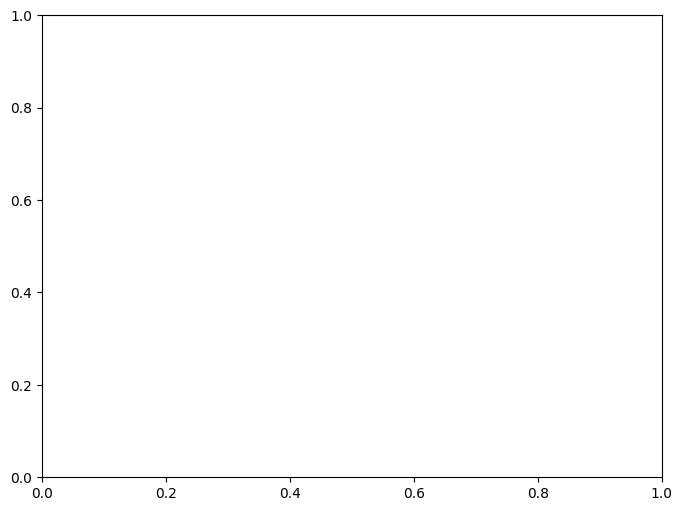

In [22]:
fig, ax = plt.subplots(1,1,figsize=(8,6))
for i, CV in enumerate(wrappersCVS[:4]):
    ax.plot(CV - CV.mean(), label=f'interval {i}', alpha=0.5)
ax.legend()
plt.show()



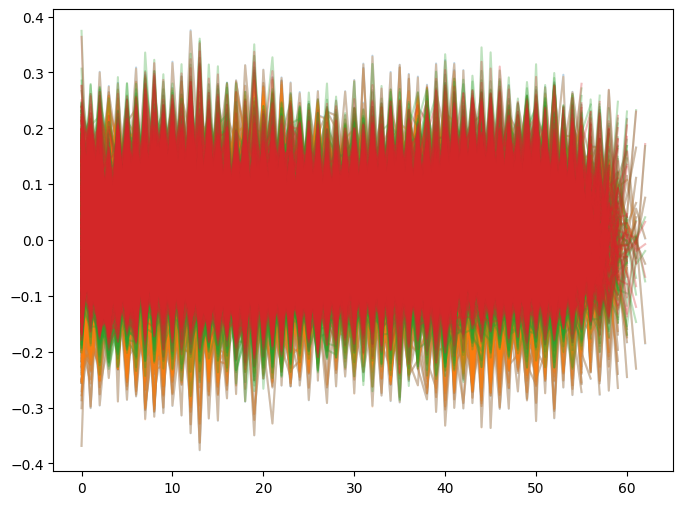

In [27]:
fig, ax = plt.subplots(1,1,figsize=(8,6))
for i, CVs in enumerate(wrappersCVSperatom[:4]):
    for CV in CVs[::1]:
        ax.plot(CV - CV.mean(), label=f'interval {i}', alpha=0.3, color=f'C{i}')
#ax.legend()
plt.show()

In [ ]:
p = np.mean(h)

    f, S = scipy.signal.periodogram(h_fluct,fs= 1/dt, detrend=None, axis=0)
    S = np.mean(S, axis = 1)
    S[1:-1] = S[1:-1] * 0.5
    MRT = S[0]*dt/(p*(1-p))
    return MRT

In [ ]:
import scipy
def get_periodo(CV, dt, ax, i):
    CV = (CV - CV.mean())/np.std(CV)
    time = np.arange(0, len(CV), dt)
    # Fourier transform
    f, S = scipy.signal.periodogram(CV,fs= 1/dt, detrend=None, axis=0)

    # Plot spectrum
    ax.plot(f, S, label=f'{i}', alpha=0.75)
    ax.legend()

In [ ]:
def get_FFT(CV, dt, ax, i):
    CV = (CV - CV.mean())/np.std(CV)
    time = np.arange(0, len(CV), dt)
    # Fourier transform
    fft_vals = np.fft.fft(CV)
    freqs = np.fft.fftfreq(len(CV), dt)
    freqs, fft_vals = welch(CV, fs=1/dt)
    
    # Take only positive frequencies
    mask = freqs > 0
    freqs = freqs[mask]
    power = np.abs(fft_vals[mask])**2


    # Plot spectrum
    ax.plot(freqs, power, label=f'{i}', alpha=0.75)
    ax.legend()
    

In [ ]:
def get_FFT_peratom(CV_peratom, dt, ax, i):
    frequencies = []
    powers = []
    for CV in CV_peratom[::10]:
        CV = (CV - CV.mean())/CV.max()
        time = np.arange(0, len(CV), dt)
        # Fourier transform
        fft_vals = np.fft.fft(CV)
        freqs = np.fft.fftfreq(len(CV), dt)
        freqs, fft_vals = welch(CV, fs=1/dt)
        # Take only positive frequencies
        mask = freqs > 0
        freqs = freqs[mask]
        power = np.abs(fft_vals[mask])**2
        frequencies.append(freqs)
        powers.append(power)
        print("  ")
        print(freqs)

        # Plot spectrum
        ax.plot(freqs, power, label=f'{i}', alpha=0.2, color=f"C{i}")
    

In [ ]:
print(len(systems))

In [ ]:
calculate = 1
dt = 0.1 # in ps
fig, ax = plt.subplots(1,1,figsize=(5,4))

if calculate:
    allCVS = []
    wrappersCVS = []
    wrappersCVSperatom = []
    for i, model in enumerate(wrappers):
        CV, CV_peratom = get_CV(model, systems[:1000])
        #allCVS.append(CV)
        wrappersCVS.append(CV)
        wrappersCVSperatom.append(CV_peratom)

for i, CV in enumerate([wrappersCVS[i] for i in range(4)]):
#for i, CV in enumerate(wrappersCVS):
    #get_FFT(CV, dt, ax, i)
    get_periodo(CV, dt, ax, i)

#for i, CV in enumerate([wrappersCVSperatom[i] for i in range(4)]):
#    get_FFT_peratom(CV, dt, ax, i)

ax.set_xlabel("Frequency")
ax.set_ylabel("Amplitude")
#ax.set_ylim(1e-4, 100)
ax.set_xscale('log')
#ax.set_yscale('log')
#ax.set_xticks([1e-5/dt, 1e-4/dt, 1e-3/dt, 1e-2/dt, 1e-1/dt, 1/dt])
#ax.set_xticklabels([r'$\frac{1}{100000dt}$',r'$\frac{1}{10000dt}$',r'$\frac{1}{1000dt}$',r'$\frac{1}{100dt}$',r'$\frac{1}{10dt}$', r'$\frac{1}{dt}$'])
#ax.set_xlim(0,10)
#ax.legend()
plt.savefig(f'wrapper_FFT-dt100fs-timeavg.png')

In [44]:
def integrated_autocorrelation_time(cv, dt):
    cv = np.asarray(cv)
    cv = cv - np.mean(cv)
    N = len(cv)

    # FFT-based autocorrelation (fast and stable)
    f = np.fft.fft(cv, n=2*N)
    acf = np.fft.ifft(f * np.conjugate(f))[:N].real
    acf /= acf[0]  # normalize

    # Find first zero crossing
    positive = np.where(acf > 0)[0]
    if len(positive) == 0:
        return dt

    cutoff = positive[-1]  # last positive value

    tau_int = dt * (1 + 2 * np.sum(acf[1:cutoff]))
    return tau_int, acf

def effective_diffusion_coefficient(cv, dt):
    cv = np.asarray(cv)
    increments = np.diff(cv)
    D_eff = np.var(increments) / (2 * dt)
    return D_eff

In [47]:
dt

0.002

In [45]:
acfs = []
for i, CV in enumerate(wrappersCVS):
    ACT, ACF = integrated_autocorrelation_time(CV, dt)
    acfs.append(ACF)
    EDC = effective_diffusion_coefficient(CV, dt)
    print(f'{i}: Integrated Auto Correlation Time {round(ACT,4)}         Effective Difussion Coefficient {round(EDC,4)}')

0: Integrated Auto Correlation Time 0.0         Effective Difussion Coefficient 0.1583
1: Integrated Auto Correlation Time 0.0         Effective Difussion Coefficient 0.1397
2: Integrated Auto Correlation Time -0.0         Effective Difussion Coefficient 0.0837
3: Integrated Auto Correlation Time -0.0         Effective Difussion Coefficient 0.053
4: Integrated Auto Correlation Time -0.0         Effective Difussion Coefficient 3.4449
5: Integrated Auto Correlation Time -0.0         Effective Difussion Coefficient 3.9544
6: Integrated Auto Correlation Time -0.0         Effective Difussion Coefficient 4.0546
7: Integrated Auto Correlation Time -0.0         Effective Difussion Coefficient 4.4362
8: Integrated Auto Correlation Time -0.0         Effective Difussion Coefficient 5.8534
9: Integrated Auto Correlation Time 0.0         Effective Difussion Coefficient 9.5359
10: Integrated Auto Correlation Time 0.0         Effective Difussion Coefficient 11.1832
11: Integrated Auto Correlation Tim

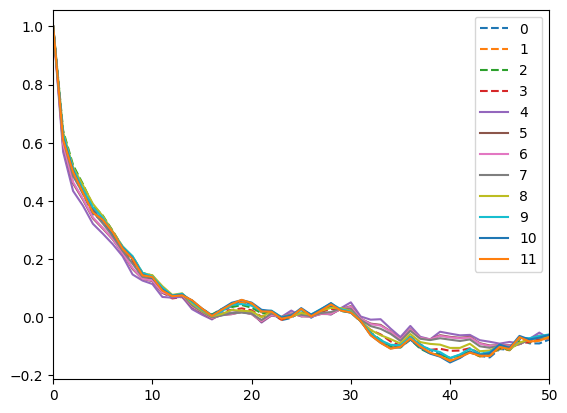

In [46]:
fig, ax = plt.subplots()
for i, acf in enumerate(acfs):
    if i < 4:
        ls = "--"
    else:
        ls = "-"
    ax.plot(acf, label=f'{i}', ls=ls)
ax.set_xlim(0, 50)
ax.legend()

In [ ]:
calculate = 0
dt = 0.002 # in ps
fig, ax = plt.subplots(1,1,figsize=(5,4))

if calculate:
    allCVS = []
    wrappersCVS = []
    wrappersCVSperatom = []
    for i, model in enumerate(wrappers):
        CV, CV_peratom = get_CV(model, systems[:10000])
        #allCVS.append(CV)
        wrappersCVS.append(CV)
        wrappersCVSperatom.append(CV_peratom)

for i, CV in enumerate([wrappersCVS[i] for i in range(4)]):
#for i, CV in enumerate(wrappersCVS):
    get_FFT(CV, dt, ax, i)

ax.set_xlabel("Frequency")
ax.set_ylabel("Amplitude")
#ax.set_ylim(1e-4, 100)
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xticks([1e-5/dt, 1e-4/dt, 1e-3/dt, 1e-2/dt, 1e-1/dt, 1/dt])
ax.set_xticklabels([r'$\frac{1}{100000dt}$',r'$\frac{1}{10000dt}$',r'$\frac{1}{1000dt}$',r'$\frac{1}{100dt}$',r'$\frac{1}{10dt}$', r'$\frac{1}{dt}$'])
#ax.set_xlim(0,10)
ax.legend()
plt.savefig(f'wrapper_FFT-dt100fs-timeavg.png')